# Structure-Aware Keyphrase Extraction (SAKE)
## Methodology & Experiments

This notebook implements the full methodology from the project proposal:
1. **TF-IDF Baseline** — standard phrase-level TF-IDF ranking
2. **Positional Weighting** ($W_{\text{position}}$) — earlier phrases score higher
3. **Section-Aware Weighting** ($W_{\text{structure}}$) — title/abstract phrases boosted
4. **Semantic Relevance** ($W_{\text{topic}}$) — LDA topic similarity
5. **Combined Scoring** — $\text{Score}(t) = \text{TF-IDF}(t) \cdot W_{\text{position}}(t) \cdot W_{\text{structure}}(t) \cdot W_{\text{topic}}(t)$
6. **Ablation Study** with Precision, Recall, F1 @ K

---
## 1. Load Preprocessed Data

In [5]:
import pickle
import math
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.stem import PorterStemmer

warnings.filterwarnings('ignore')

with open('preprocessed_krapivin.pkl', 'rb') as f:
    data = pickle.load(f)

print(f'Loaded {len(data)} documents')
print(f'Keys per document: {list(data[0].keys())}')
print(f'Example ground truth: {data[0]["ground_truth"]}')

Loaded 2304 documents
Keys per document: ['doc_id', 'all_phrases', 'title_phrases', 'abstract_phrases', 'body_phrases', 'ground_truth']
Example ground truth: ['outlier detection', 'spatial data mining']


---
## 2. Evaluation Framework

We evaluate with **Precision@K**, **Recall@K**, and **F1@K**, matching predictions to gold keyphrases after Porter stemming (standard practice in keyphrase extraction literature).

In [6]:
stemmer = PorterStemmer()

def stem_phrase(phrase):
    """Lowercase and stem each token in a phrase for fuzzy matching."""
    return ' '.join(stemmer.stem(w) for w in phrase.lower().split())

def evaluate_single(predicted, gold, k):
    """Precision, Recall, F1 for a single document at cutoff K."""
    pred_stemmed = set(stem_phrase(p) for p in predicted[:k])
    gold_stemmed = set(stem_phrase(g) for g in gold)
    if not gold_stemmed:
        return 0.0, 0.0, 0.0
    tp = len(pred_stemmed & gold_stemmed)
    precision = tp / k if k > 0 else 0.0
    recall = tp / len(gold_stemmed)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

def evaluate_corpus(ranking_func, data, ks=[5, 10, 15]):
    """Macro-averaged P/R/F1 across all documents for multiple K values."""
    results = {k: {'P': [], 'R': [], 'F1': []} for k in ks}
    for doc in data:
        if not doc['ground_truth']:
            continue
        ranked = ranking_func(doc)
        for k in ks:
            p, r, f1 = evaluate_single(ranked, doc['ground_truth'], k)
            results[k]['P'].append(p)
            results[k]['R'].append(r)
            results[k]['F1'].append(f1)
    summary = {}
    for k in ks:
        summary[k] = {
            'P': np.mean(results[k]['P']),
            'R': np.mean(results[k]['R']),
            'F1': np.mean(results[k]['F1'])
        }
    return summary

def print_results(name, summary):
    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    for k, metrics in summary.items():
        print(f'  @{k:>2d}  P={metrics["P"]:.4f}  R={metrics["R"]:.4f}  F1={metrics["F1"]:.4f}')

# Quick sanity check
print('Evaluation framework ready.')
print(f'Documents with ground truth: {sum(1 for d in data if d["ground_truth"])}')

Evaluation framework ready.
Documents with ground truth: 2283


---
## 3. TF-IDF Baseline

Compute phrase-level TF-IDF across the corpus. For each document, TF is the count of a phrase within that document, and IDF is computed from the full corpus.

In [7]:
N = len(data)

# Build document frequency (DF) across the entire corpus
doc_freq = Counter()
for doc in data:
    unique_phrases = set(doc['all_phrases'])
    for phrase in unique_phrases:
        doc_freq[phrase] += 1

print(f'Vocabulary size: {len(doc_freq)}')
print(f'Top-20 most common phrases: {doc_freq.most_common(20)}')

Vocabulary size: 720778
Top-20 most common phrases: [('case', 2244), ('section', 2233), ('paper', 2216), ('example', 2167), ('number', 2146), ('set', 2112), ('order', 2074), ('problem', 2040), ('time', 2020), ('value', 1907), ('fact', 1872), ('possible', 1840), ('work', 1812), ('application', 1803), ('way', 1777), ('term', 1743), ('algorithm', 1733), ('approach', 1727), ('use', 1719), ('system', 1641)]


In [8]:
def compute_tfidf(doc):
    """Return {phrase: tfidf_score} for a single document."""
    tf = Counter(doc['all_phrases'])
    total = len(doc['all_phrases'])
    scores = {}
    for phrase, count in tf.items():
        tf_val = count / total
        idf_val = math.log(N / (1 + doc_freq.get(phrase, 0)))
        scores[phrase] = tf_val * idf_val
    return scores

def rank_tfidf(doc):
    """Rank phrases by TF-IDF score (descending)."""
    scores = compute_tfidf(doc)
    ranked = sorted(scores.keys(), key=lambda p: scores[p], reverse=True)
    return ranked

# Evaluate
tfidf_results = evaluate_corpus(rank_tfidf, data)
print_results('TF-IDF Baseline', tfidf_results)


  TF-IDF Baseline
  @ 5  P=0.0979  R=0.1334  F1=0.1068
  @10  P=0.0789  R=0.2145  F1=0.1104
  @15  P=0.0664  R=0.2700  F1=0.1027


---
## 4. Positional Weighting ($W_{\text{position}}$)

Phrases appearing **earlier** in the document are more likely to be keyphrases. We use the reciprocal of the first occurrence position (normalized) as the positional weight:

$$W_{\text{position}}(t) = \frac{1}{1 + \frac{\text{first\_pos}(t)}{\text{total\_phrases}}}$$

This gives phrases at position 0 a weight of 1.0, decaying toward 0.5 for phrases at the end.

In [9]:
def compute_position_weight(doc):
    """Return {phrase: position_weight} based on first occurrence."""
    all_phrases = doc['all_phrases']
    total = len(all_phrases)
    if total == 0:
        return {}
    first_pos = {}
    for i, phrase in enumerate(all_phrases):
        if phrase not in first_pos:
            first_pos[phrase] = i
    weights = {}
    for phrase, pos in first_pos.items():
        weights[phrase] = 1.0 / (1.0 + pos / total)
    return weights

def rank_tfidf_position(doc):
    tfidf_scores = compute_tfidf(doc)
    pos_weights = compute_position_weight(doc)
    combined = {}
    for phrase in tfidf_scores:
        combined[phrase] = tfidf_scores[phrase] * pos_weights.get(phrase, 0.5)
    return sorted(combined.keys(), key=lambda p: combined[p], reverse=True)

# Evaluate
tfidf_pos_results = evaluate_corpus(rank_tfidf_position, data)
print_results('TF-IDF + Position', tfidf_pos_results)


  TF-IDF + Position
  @ 5  P=0.1093  R=0.1496  F1=0.1196
  @10  P=0.0859  R=0.2340  F1=0.1201
  @15  P=0.0722  R=0.2957  F1=0.1117


---
## 5. Section-Aware Weighting ($W_{\text{structure}}$)

Phrases in the **title** or **abstract** are much more likely to be keyphrases than phrases only in the body. We assign multiplicative section weights:

| Appearance | Weight |
|---|---|
| Title | $\alpha_T$ |
| Abstract | $\alpha_A$ |
| Body only | 1.0 |

If a phrase appears in multiple sections, we take the **maximum** weight.

In [10]:
ALPHA_TITLE = 3.0
ALPHA_ABSTRACT = 2.0
ALPHA_BODY = 1.0

def compute_section_weight(doc):
    """Return {phrase: section_weight} based on where a phrase appears."""
    title_set = set(doc['title_phrases'])
    abstract_set = set(doc['abstract_phrases'])
    all_unique = set(doc['all_phrases'])
    weights = {}
    for phrase in all_unique:
        w = ALPHA_BODY
        if phrase in abstract_set:
            w = max(w, ALPHA_ABSTRACT)
        if phrase in title_set:
            w = max(w, ALPHA_TITLE)
        weights[phrase] = w
    return weights

def rank_tfidf_pos_section(doc):
    tfidf_scores = compute_tfidf(doc)
    pos_weights = compute_position_weight(doc)
    sec_weights = compute_section_weight(doc)
    combined = {}
    for phrase in tfidf_scores:
        combined[phrase] = (
            tfidf_scores[phrase]
            * pos_weights.get(phrase, 0.5)
            * sec_weights.get(phrase, 1.0)
        )
    return sorted(combined.keys(), key=lambda p: combined[p], reverse=True)

# Evaluate
tfidf_pos_sec_results = evaluate_corpus(rank_tfidf_pos_section, data)
print_results('TF-IDF + Position + Section', tfidf_pos_sec_results)


  TF-IDF + Position + Section
  @ 5  P=0.1400  R=0.1938  F1=0.1539
  @10  P=0.1050  R=0.2899  F1=0.1470
  @15  P=0.0845  R=0.3473  F1=0.1307


---
## 6. Semantic Relevance via LDA ($W_{\text{topic}}$)

We train an LDA topic model on the corpus. For each document, we compute a **topic distribution**, then score each candidate phrase by its cosine similarity to the document's topic vector. This captures topical fit beyond raw frequency.

In [13]:
from gensim import corpora, models
from numpy.linalg import norm

# Build corpus for LDA: each document is its list of phrases
texts = [doc['all_phrases'] for doc in data]

dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus_bow = [dictionary.doc2bow(text) for text in texts]

print(f'Dictionary size after filtering: {len(dictionary)}')

NUM_TOPICS = 20
lda_model = models.LdaModel(
    corpus=corpus_bow,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=10,
    alpha='auto',
    eta='auto'
)

print(f'\nLDA model trained with {NUM_TOPICS} topics.')
for i in range(min(5, NUM_TOPICS)):
    print(f'  Topic {i}: {lda_model.print_topic(i, topn=6)}')

Dictionary size after filtering: 30912

LDA model trained with 20 topics.
  Topic 0: 0.062*"node" + 0.019*"path" + 0.011*"variable" + 0.010*"tree" + 0.007*"cost" + 0.007*"arc"
  Topic 1: 0.053*"edge" + 0.051*"vertex" + 0.048*"graph" + 0.020*"node" + 0.019*"path" + 0.013*"log"
  Topic 2: 0.021*"job" + 0.016*"probability" + 0.013*"adversary" + 0.011*"log" + 0.011*"interval" + 0.011*"theorem"
  Topic 3: 0.095*"processor" + 0.017*"column" + 0.014*"row" + 0.013*"element" + 0.013*"matrix" + 0.012*"block"
  Topic 4: 0.035*"node" + 0.029*"message" + 0.021*"network" + 0.014*"packet" + 0.011*"path" + 0.010*"link"


In [14]:
def get_doc_topic_vec(bow):
    """Dense topic vector for a document."""
    topic_dist = lda_model.get_document_topics(bow, minimum_probability=0.0)
    return np.array([prob for _, prob in topic_dist])

def get_phrase_topic_vec(phrase):
    """Dense topic vector for a single phrase (treated as a mini-document)."""
    bow = dictionary.doc2bow(phrase.split())
    if not bow:
        return np.zeros(NUM_TOPICS)
    topic_dist = lda_model.get_document_topics(bow, minimum_probability=0.0)
    return np.array([prob for _, prob in topic_dist])

def cosine_sim(a, b):
    denom = norm(a) * norm(b)
    if denom == 0:
        return 0.0
    return np.dot(a, b) / denom

# Precompute document topic vectors
doc_topic_vecs = [get_doc_topic_vec(bow) for bow in corpus_bow]

print('Document topic vectors precomputed.')

Document topic vectors precomputed.


In [15]:
def compute_topic_weight(doc, doc_idx):
    """Return {phrase: topic_similarity_weight} for a document."""
    doc_vec = doc_topic_vecs[doc_idx]
    unique_phrases = set(doc['all_phrases'])
    weights = {}
    for phrase in unique_phrases:
        sim = cosine_sim(doc_vec, get_phrase_topic_vec(phrase))
        # Shift to [0.5, 1.5] range so it modulates rather than zeroes out
        weights[phrase] = 0.5 + sim
    return weights

def rank_full_model(doc, doc_idx):
    tfidf_scores = compute_tfidf(doc)
    pos_weights = compute_position_weight(doc)
    sec_weights = compute_section_weight(doc)
    topic_weights = compute_topic_weight(doc, doc_idx)
    combined = {}
    for phrase in tfidf_scores:
        combined[phrase] = (
            tfidf_scores[phrase]
            * pos_weights.get(phrase, 0.5)
            * sec_weights.get(phrase, 1.0)
            * topic_weights.get(phrase, 0.5)
        )
    return sorted(combined.keys(), key=lambda p: combined[p], reverse=True)

# Evaluate the full model
def rank_full_wrapper(doc):
    doc_idx = next(i for i, d in enumerate(data) if d['doc_id'] == doc['doc_id'])
    return rank_full_model(doc, doc_idx)

# Build a fast lookup for doc_id -> index
doc_id_to_idx = {d['doc_id']: i for i, d in enumerate(data)}

def rank_full_fast(doc):
    return rank_full_model(doc, doc_id_to_idx[doc['doc_id']])

print('Computing full model evaluation (this may take a few minutes)...')
full_results = evaluate_corpus(rank_full_fast, data)
print_results('TF-IDF + Position + Section + Semantic', full_results)

Computing full model evaluation (this may take a few minutes)...

  TF-IDF + Position + Section + Semantic
  @ 5  P=0.1391  R=0.1938  F1=0.1534
  @10  P=0.1031  R=0.2857  F1=0.1446
  @15  P=0.0835  R=0.3461  F1=0.1293


---
## 7. Ablation Study — Summary Table

In [16]:
# Also evaluate TF-IDF + Section (without position) for completeness
def rank_tfidf_section(doc):
    tfidf_scores = compute_tfidf(doc)
    sec_weights = compute_section_weight(doc)
    combined = {}
    for phrase in tfidf_scores:
        combined[phrase] = tfidf_scores[phrase] * sec_weights.get(phrase, 1.0)
    return sorted(combined.keys(), key=lambda p: combined[p], reverse=True)

tfidf_sec_results = evaluate_corpus(rank_tfidf_section, data)
print_results('TF-IDF + Section (no position)', tfidf_sec_results)


  TF-IDF + Section (no position)
  @ 5  P=0.1359  R=0.1885  F1=0.1495
  @10  P=0.0998  R=0.2746  F1=0.1396
  @15  P=0.0809  R=0.3330  F1=0.1253


In [17]:
all_results = {
    'TF-IDF': tfidf_results,
    'TF-IDF + Pos': tfidf_pos_results,
    'TF-IDF + Pos + Sec': tfidf_pos_sec_results,
    'TF-IDF + Pos + Sec + Sem (Full)': full_results,
}

rows = []
for model_name, summary in all_results.items():
    for k, metrics in summary.items():
        rows.append({
            'Model': model_name,
            'K': k,
            'Precision': round(metrics['P'], 4),
            'Recall': round(metrics['R'], 4),
            'F1': round(metrics['F1'], 4)
        })

results_df = pd.DataFrame(rows)

print('\n' + '='*70)
print('  ABLATION STUDY — FULL RESULTS')
print('='*70)
for k in [5, 10, 15]:
    print(f'\n--- @K={k} ---')
    subset = results_df[results_df['K'] == k][['Model', 'Precision', 'Recall', 'F1']]
    print(subset.to_string(index=False))

results_df.to_csv('ablation_results.csv', index=False)
print('\nResults saved to ablation_results.csv')


  ABLATION STUDY — FULL RESULTS

--- @K=5 ---
                          Model  Precision  Recall     F1
                         TF-IDF     0.0979  0.1334 0.1068
                   TF-IDF + Pos     0.1093  0.1496 0.1196
             TF-IDF + Pos + Sec     0.1400  0.1938 0.1539
TF-IDF + Pos + Sec + Sem (Full)     0.1391  0.1938 0.1534

--- @K=10 ---
                          Model  Precision  Recall     F1
                         TF-IDF     0.0789  0.2145 0.1104
                   TF-IDF + Pos     0.0859  0.2340 0.1201
             TF-IDF + Pos + Sec     0.1050  0.2899 0.1470
TF-IDF + Pos + Sec + Sem (Full)     0.1031  0.2857 0.1446

--- @K=15 ---
                          Model  Precision  Recall     F1
                         TF-IDF     0.0664  0.2700 0.1027
                   TF-IDF + Pos     0.0722  0.2957 0.1117
             TF-IDF + Pos + Sec     0.0845  0.3473 0.1307
TF-IDF + Pos + Sec + Sem (Full)     0.0835  0.3461 0.1293

Results saved to ablation_results.csv


---
## 8. Visualization

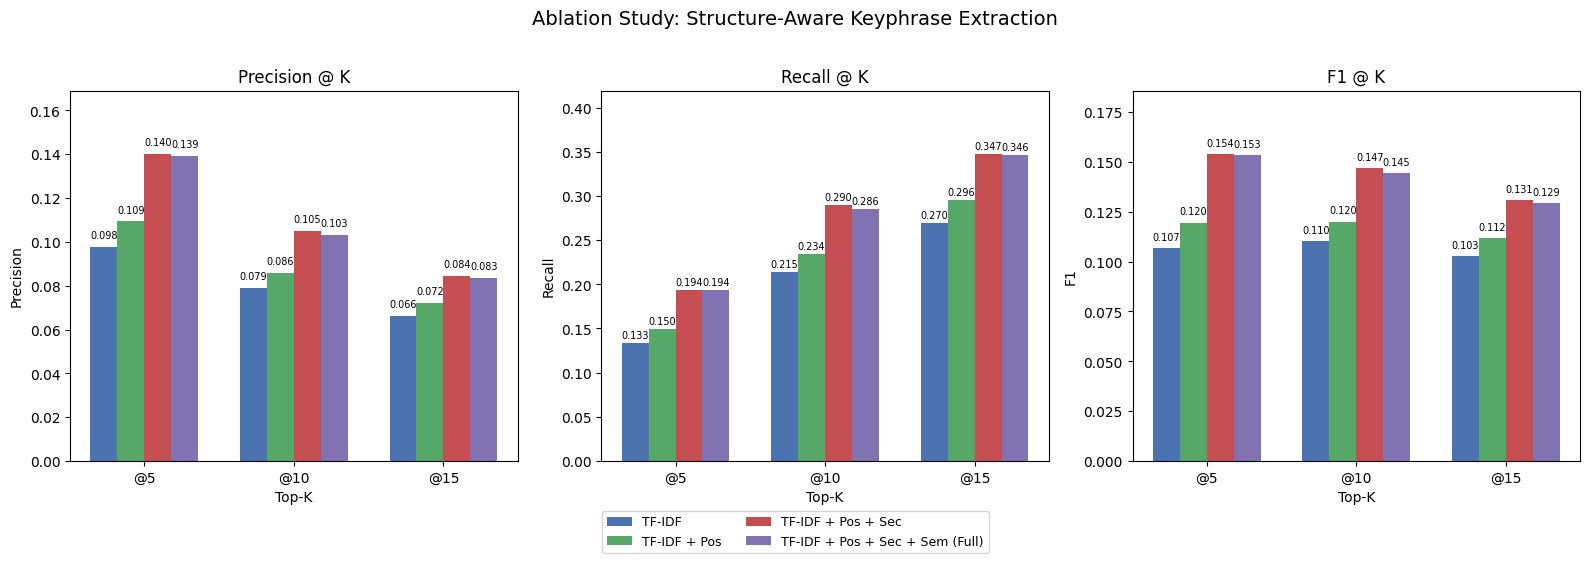

Chart saved to ablation_chart.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_key_map = {'Precision': 'P', 'Recall': 'R', 'F1': 'F1'}
metrics_names = ['Precision', 'Recall', 'F1']
ks = [5, 10, 15]
model_names = list(all_results.keys())
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for ax_idx, metric in enumerate(metrics_names):
    ax = axes[ax_idx]
    x = np.arange(len(ks))
    width = 0.18
    key = metric_key_map[metric]
    for m_idx, model_name in enumerate(model_names):
        vals = [all_results[model_name][k][key] for k in ks]
        bars = ax.bar(x + m_idx * width, vals, width,
                      label=model_name if ax_idx == 0 else '', color=colors[m_idx])
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7)
    ax.set_xlabel('Top-K')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} @ K')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels([f'@{k}' for k in ks])
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

fig.legend(model_names, loc='lower center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.08))
fig.suptitle('Ablation Study: Structure-Aware Keyphrase Extraction', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('ablation_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to ablation_chart.png')

---
## 9. Qualitative Analysis — Sample Predictions

In [20]:
np.random.seed(42)
sample_indices = np.random.choice(
    [i for i, d in enumerate(data) if d['ground_truth']], size=5, replace=False
)

for idx in sample_indices:
    doc = data[idx]
    gold = set(stem_phrase(g) for g in doc['ground_truth'])
    baseline_top10 = rank_tfidf(doc)[:10]
    full_top10 = rank_full_model(doc, idx)[:10]

    print(f'\n{"="*70}')
    print(f'Doc ID: {doc["doc_id"]}')
    print(f'Gold keyphrases: {doc["ground_truth"]}')
    print(f'\n  TF-IDF Baseline Top-10:')
    for i, p in enumerate(baseline_top10, 1):
        match = '  ✓' if stem_phrase(p) in gold else ''
        print(f'    {i:>2}. {p}{match}')
    print(f'\n  Full Model Top-10:')
    for i, p in enumerate(full_top10, 1):
        match = '  ✓' if stem_phrase(p) in gold else ''
        print(f'    {i:>2}. {p}{match}')


Doc ID: 377018
Gold keyphrases: ['time warp', 'checkpointing', 'optimistic synchronization']

  TF-IDF Baseline Top-10:
     1. checkpoint  ✓
     2. selection policy
     3. ct
     4. lp
     5. checkpointing technique
     6. event
     7. rollback
     8. cr
     9. cost model
    10. checkpoint interval

  Full Model Top-10:
     1. checkpoint  ✓
     2. rollback
     3. checkpointing technique
     4. event
     5. cost model
     6. checkpoint position
     7. ct
     8. selection policy
     9. lp
    10. fast execution

Doc ID: 207992
Gold keyphrases: ['computational complexity', 'complexity classes']

  TF-IDF Baseline Top-10:
     1. complexity core
     2. dtime
     3. language
     4. hard language
     5. incompressible
     6. weakly
     7. np
     8. density function
     9. reduction
    10. complete language

  Full Model Top-10:
     1. dtime
     2. language
     3. hard language
     4. complexity core
     5. np
     6. complete language
     7. measure
     8.

---
## 10. Hyperparameter Sensitivity Analysis

Test different section weight configurations to understand sensitivity.

In [21]:
configs = [
    (2.0, 1.5, 'Low: T=2.0, A=1.5'),
    (3.0, 2.0, 'Mid: T=3.0, A=2.0'),
    (5.0, 3.0, 'High: T=5.0, A=3.0'),
    (8.0, 4.0, 'Very High: T=8.0, A=4.0'),
]

sensitivity_rows = []
for alpha_t, alpha_a, label in configs:
    def make_ranker(at, aa):
        def ranker(doc):
            tfidf_scores = compute_tfidf(doc)
            pos_weights = compute_position_weight(doc)
            title_set = set(doc['title_phrases'])
            abstract_set = set(doc['abstract_phrases'])
            combined = {}
            for phrase in tfidf_scores:
                sw = 1.0
                if phrase in abstract_set: sw = max(sw, aa)
                if phrase in title_set: sw = max(sw, at)
                combined[phrase] = tfidf_scores[phrase] * pos_weights.get(phrase, 0.5) * sw
            return sorted(combined.keys(), key=lambda p: combined[p], reverse=True)
        return ranker

    ranker = make_ranker(alpha_t, alpha_a)
    res = evaluate_corpus(ranker, data)
    for k, m in res.items():
        sensitivity_rows.append({'Config': label, 'K': k,
                                  'F1': round(m['F1'], 4)})
    print(f'{label}: F1@5={res[5]["F1"]:.4f}, F1@10={res[10]["F1"]:.4f}, F1@15={res[15]["F1"]:.4f}')

sens_df = pd.DataFrame(sensitivity_rows)
print('\nSensitivity analysis complete.')

Low: T=2.0, A=1.5: F1@5=0.1446, F1@10=0.1367, F1@15=0.1252
Mid: T=3.0, A=2.0: F1@5=0.1539, F1@10=0.1470, F1@15=0.1307
High: T=5.0, A=3.0: F1@5=0.1625, F1@10=0.1535, F1@15=0.1354
Very High: T=8.0, A=4.0: F1@5=0.1668, F1@10=0.1580, F1@15=0.1368

Sensitivity analysis complete.


---
## 11. Error Analysis

In [22]:
missed_types = Counter()
false_positive_count = 0
total_gold = 0
total_hits = 0

for idx, doc in enumerate(data):
    if not doc['ground_truth']:
        continue
    top15 = rank_full_model(doc, idx)[:15]
    pred_stemmed = set(stem_phrase(p) for p in top15)
    gold_stemmed = {stem_phrase(g): g for g in doc['ground_truth']}
    total_gold += len(gold_stemmed)
    total_hits += len(pred_stemmed & set(gold_stemmed.keys()))

    for gs, original in gold_stemmed.items():
        if gs not in pred_stemmed:
            n_words = len(original.split())
            if n_words == 1:
                missed_types['unigram'] += 1
            elif n_words == 2:
                missed_types['bigram'] += 1
            else:
                missed_types['3+ gram'] += 1

print(f'Overall hit rate @15: {total_hits}/{total_gold} = {total_hits/total_gold:.3f}')
print(f'\nMissed keyphrase breakdown by n-gram type:')
for k, v in missed_types.most_common():
    print(f'  {k}: {v}')

Overall hit rate @15: 2863/8581 = 0.334

Missed keyphrase breakdown by n-gram type:
  bigram: 3534
  unigram: 1152
  3+ gram: 1032


---
## 12. Summary

This notebook implemented the full **Structure-Aware Keyphrase Extraction (SAKE)** pipeline on the Krapivin benchmark (2,304 documents).

### Ablation Study

| Model Configuration | Description |
|---|---|
| **TF-IDF** | Bag-of-words frequency baseline |
| **+ Position** | Boost phrases appearing early in the document |
| **+ Section** | Boost phrases from title/abstract |
| **+ Semantic (Full SAKE)** | LDA topic similarity for topical fit |

### Combined Scoring Formula

$$\text{Score}(t) = \text{TF-IDF}(t) \cdot W_{\text{position}}(t) \cdot W_{\text{structure}}(t) \cdot W_{\text{topic}}(t)$$

The ablation results above show the incremental contribution of each signal to keyphrase extraction performance.